In [ ]:
!pip -q install pandas scikit-learn onnx onnxruntime

import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import onnx
import onnxruntime as ort

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.6 MB/s eta 0:00:00


device(type='cuda')

In [ ]:
df = pd.read_csv("/content/FlexSensorDataset.csv")

required = {"Value", "Bending Angle"}
if not required.issubset(df.columns):
    raise ValueError(f"CSV must contain columns {required}. Found: {list(df.columns)}")

# Clean
df = df.dropna(subset=["Value", "Bending Angle"]).copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df["Bending Angle"] = pd.to_numeric(df["Bending Angle"], errors="coerce")
df = df.dropna(subset=["Value", "Bending Angle"]).copy()

# Robust mapping: if exactly {0,45,90}, fix order; else sorted unique -> 0..k-1
unique_labels = sorted(df["Bending Angle"].unique().tolist())
if set(unique_labels) == {0, 45, 90}:
    label_to_id = {0:0, 45:1, 90:2}
else:
    label_to_id = {lab:i for i, lab in enumerate(unique_labels)}
id_to_label = {v:k for k,v in label_to_id.items()}

y = df["Bending Angle"].map(label_to_id).astype(int).values
X = df["Value"].values.astype(np.float32).reshape(-1, 1)

# Stratified 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Split sizes -> train/val/test:", len(X_train), len(X_val), len(X_test))
print("Label map:", label_to_id)

# Normalization stats from train set
mean = float(X_train.mean())
std  = float(X_train.std())
if std < 1e-8: std = 1.0
norm_stats = {"mean": mean, "std": std}
norm_stats

Split sizes -> train/val/test: 503 108 108
Label map: {0: 0, 45: 1, 90: 2}


{'mean': 3562.2822265625, 'std': 398.8916931152344}

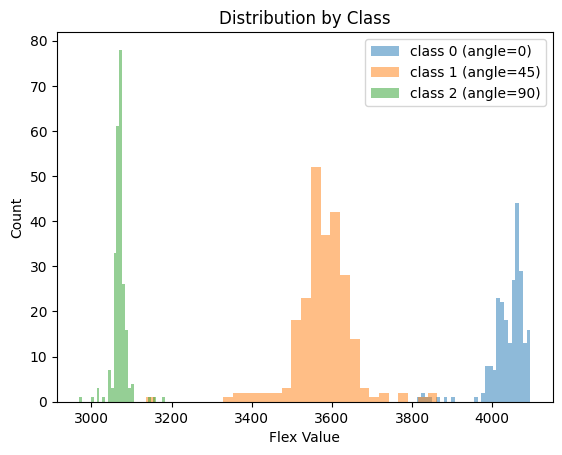

In [ ]:
plt.figure()
for cls in sorted(np.unique(y)):
    plt.hist(X[y==cls].ravel(), bins=30, alpha=0.5, label=f"class {cls} (angle={id_to_label[cls]})")
plt.xlabel("Flex Value"); plt.ylabel("Count"); plt.title("Distribution by Class")
plt.legend(); plt.show()

In [ ]:
class FlexDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()  # (N,1)
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FlexDataset(X_train, y_train)
val_ds   = FlexDataset(X_val, y_val)
test_ds  = FlexDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

In [ ]:
class TinyMLP(nn.Module):
    def __init__(self, hidden1=8, hidden2=8, n_classes=3, mean=0.0, std=1.0):
        super().__init__()
        # store normalization stats as buffers (saved/exported)
        self.register_buffer("mean", torch.tensor([mean], dtype=torch.float32))
        self.register_buffer("std",  torch.tensor([std],  dtype=torch.float32))
        self.fc1 = nn.Linear(1, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, n_classes)
    def forward(self, x):
        x = (x - self.mean) / self.std
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)  # logits

n_classes = len(np.unique(y))
model = TinyMLP(hidden1=8, hidden2=8, n_classes=n_classes, mean=mean, std=std).to(device)
print("Total params:", sum(p.numel() for p in model.parameters()))
model

Total params: 115


TinyMLP(
  (fc1): Linear(in_features=1, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            total_correct += (pred == yb).sum().item()
            total += xb.size(0)
            all_preds.append(pred.cpu())
            all_targets.append(yb.cpu())
    avg_loss = total_loss / total
    acc = total_correct / total
    return avg_loss, acc, torch.cat(all_targets), torch.cat(all_preds)

def train_model(model, train_loader, val_loader, epochs=200, patience=20, lr=1e-3, weight_decay=1e-5):
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for ep in range(1, epochs+1):
        model.train()
        run_loss, run_correct, seen = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optim.step()
            run_loss += loss.item() * xb.size(0)
            run_correct += (logits.argmax(1) == yb).sum().item()
            seen += xb.size(0)

        train_loss = run_loss / seen
        train_acc  = run_correct / seen
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if ep % 20 == 0 or ep == 1:
            print(f"Epoch {ep:3d} | train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

        if wait >= patience:
            print(f"EarlyStopping @ epoch {ep}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

history = train_model(model, train_loader, val_loader, epochs=200, patience=20, lr=1e-3)

Epoch   1 | train_loss=1.0137 acc=0.4175 | val_loss=0.9601 acc=0.6667
Epoch  20 | train_loss=0.0642 acc=0.9940 | val_loss=0.0517 acc=1.0000
Epoch  40 | train_loss=0.0171 acc=0.9960 | val_loss=0.0124 acc=0.9907
Epoch  60 | train_loss=0.0148 acc=0.9940 | val_loss=0.0092 acc=0.9907
Epoch  80 | train_loss=0.0143 acc=0.9920 | val_loss=0.0102 acc=0.9907
EarlyStopping @ epoch 95


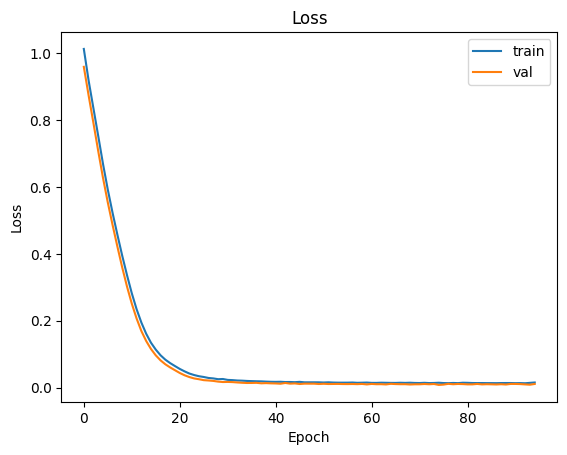

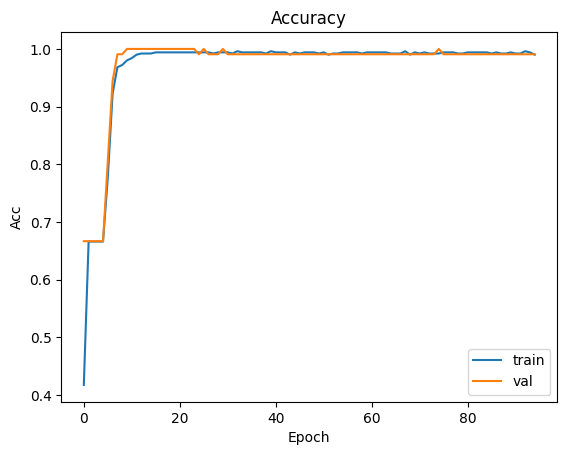

[Validation] loss=0.0077, acc=1.0000
[Test]       loss=0.0585, acc=0.9907

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
          45     1.0000    0.9722    0.9859        36
          90     0.9730    1.0000    0.9863        36

    accuracy                         0.9907       108
   macro avg     0.9910    0.9907    0.9907       108
weighted avg     0.9910    0.9907    0.9907       108

Confusion matrix (validation):
 [[36  0  0]
 [ 0 36  0]
 [ 0  0 36]]
Confusion matrix (test):
 [[36  0  0]
 [ 0 35  1]
 [ 0  0 36]]


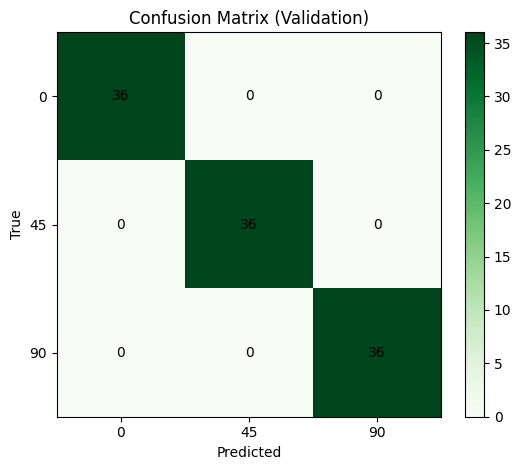

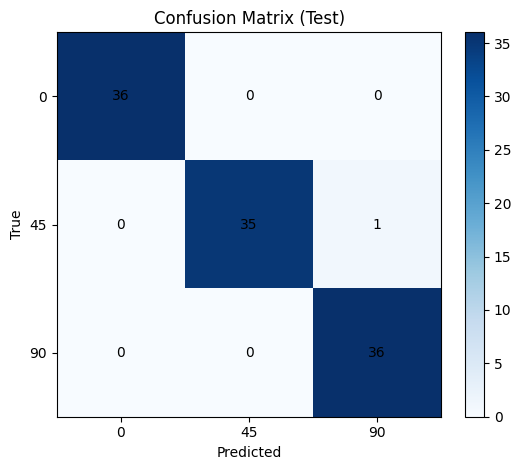

In [ ]:
# Learning curves
plt.figure(); plt.plot(history["train_loss"], label="train"); plt.plot(history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

plt.figure(); plt.plot(history["train_acc"], label="train"); plt.plot(history["val_acc"], label="val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend(); plt.show()

# Metrics
criterion = nn.CrossEntropyLoss()
val_loss, val_acc, yv_true, yv_pred = evaluate(model, val_loader, criterion)
test_loss, test_acc, yt_true, yt_pred = evaluate(model, test_loader, criterion)
print(f"[Validation] loss={val_loss:.4f}, acc={val_acc:.4f}")
print(f"[Test]       loss={test_loss:.4f}, acc={test_acc:.4f}")

print("\nClassification report (test):")
print(classification_report(
    yt_true.numpy(), yt_pred.numpy(),
    digits=4, target_names=[str(id_to_label[i]) for i in range(len(id_to_label))]
))

# Confusion matrices
cm_val  = confusion_matrix(yv_true.numpy(), yv_pred.numpy())
cm_test = confusion_matrix(yt_true.numpy(), yt_pred.numpy())
print("Confusion matrix (validation):\n", cm_val)
print("Confusion matrix (test):\n", cm_test)

# --- Validation CM (sober 'Greys') ---
plt.figure()
im = plt.imshow(cm_val, interpolation='nearest', cmap='Greens')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(id_to_label)), [f"{id_to_label[i]}" for i in range(len(id_to_label))])
plt.yticks(range(len(id_to_label)), [f"{id_to_label[i]}" for i in range(len(id_to_label))])
for (i, j), v in np.ndenumerate(cm_val):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

# --- Test CM (sober but different 'Blues') ---
plt.figure()
im2 = plt.imshow(cm_test, interpolation='nearest', cmap='Blues')
plt.colorbar(im2, fraction=0.046, pad=0.04)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(id_to_label)), [f"{id_to_label[i]}" for i in range(len(id_to_label))])
plt.yticks(range(len(id_to_label)), [f"{id_to_label[i]}" for i in range(len(id_to_label))])
for (i, j), v in np.ndenumerate(cm_test):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()